Fetching / loading APASS reference catalog...
1839 APASS reference stars in field
1474 plates found
100/1474  elapsed 112.8s
200/1474  elapsed 184.6s
300/1474  elapsed 254.7s
400/1474  elapsed 328.0s
500/1474  elapsed 442.4s
600/1474  elapsed 524.0s
700/1474  elapsed 619.1s
800/1474  elapsed 696.0s
900/1474  elapsed 760.8s
1000/1474  elapsed 814.7s
1100/1474  elapsed 869.9s
1200/1474  elapsed 920.9s
1300/1474  elapsed 968.1s
1400/1474  elapsed 1467.8s
rejection_reason
NaN                          845
target not detected          405
too few matched ref stars    224
Name: count, dtype: int64
845/1474 plates passed quality gates
ref_band
Bmag    708
Vmag    137
Name: count, dtype: int64
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA`
- Query target: `V CrA`
- Refcat: 4996 sources from `apass`
- Exposures: 7218 relevant exposures


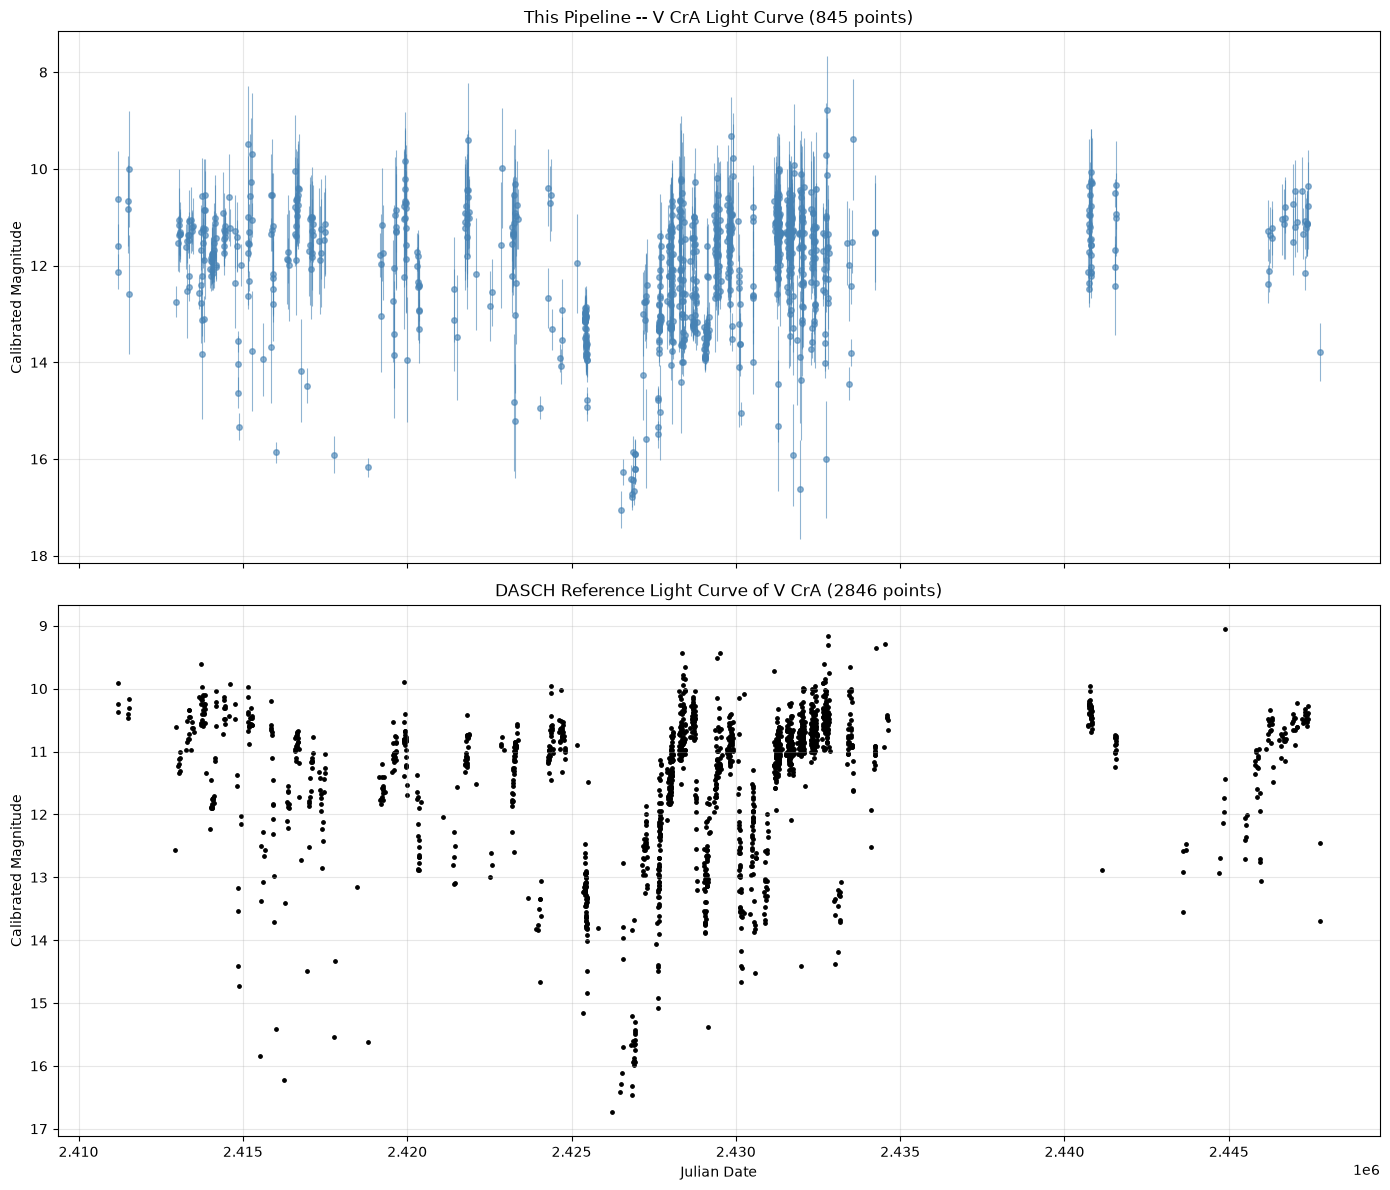

In [1]:
# DASCH-replica photometry pipeline for V CrA cutouts, plus comparison
# against the official DASCH archive light curve.
# Requires: astropy, sep (or sep-pjw), scipy, pandas, matplotlib, astroquery, daschlab
# Optional: statsmodels (better LOWESS; a fallback is used if not installed)

import os, glob, math, time, warnings
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
import sep
from scipy import stats
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as _sm_lowess
    def lowess_fit(x, y, frac=0.3):
        out = _sm_lowess(y, x, frac=frac, return_sorted=True)
        return out[:, 0], out[:, 1]
except ImportError:
    def lowess_fit(x, y, frac=0.3):
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        n = len(xs)
        span = max(int(frac * n), 4)
        fitted = np.empty(n)
        for i in range(n):
            lo = max(0, min(i - span // 2, n - span))
            hi = min(n, lo + span)
            xw, yw = xs[lo:hi], ys[lo:hi]
            if len(xw) < 2 or np.ptp(xw) == 0:
                fitted[i] = np.median(yw)
            else:
                slope, intercept, *_ = stats.linregress(xw, yw)
                fitted[i] = slope * xs[i] + intercept
        return xs, fitted

# ---------------------------------------------------------------------------
# Paths / target
# ---------------------------------------------------------------------------
VCRA_RA_DEG  = 281.884623417
VCRA_DEC_DEG = -38.158974417

CUTOUT_DIR = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\cutouts"
V_CRA_DIR  = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA"
OUTPUT_DIR = r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V_CrA\02_C_DASCH_Replica"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# DASCH.config equivalent (production SExtractor settings)
# ---------------------------------------------------------------------------
DETECT_THRESH    = 1.5
DETECT_MINAREA   = 5
DEBLEND_NTHRESH  = 32
DEBLEND_MINCONT  = 0.005
APER_ARCSEC      = 10.0
ANNULUS_GAP_PX   = 3
ANNULUS_THICK_PX = 20
SATUR_LEVEL      = 32000.0

# ---------------------------------------------------------------------------
# Calibration parameters
# ---------------------------------------------------------------------------
MATCH_RADIUS_ARCSEC  = 10.0
MIN_REF_STARS_GLOBAL = 25
NBINS_LOCAL          = 9
MIN_REF_STARS_LOCAL  = 8
SIGNIF_THRESHOLD     = 5.0
OUTLIER_SIGMA        = 3.0
EXTRAP_MARGIN_MAG    = 10.0
REF_COLOR_BLUE       = 'Bmag'
REF_COLOR_RED        = 'Vmag'
REF_BANDS            = ['Bmag', 'Vmag']  # tried per-plate; the tighter fit wins

# ---------------------------------------------------------------------------
# 1. Fetch APASS reference catalog once for the whole field (cached to disk)
# ---------------------------------------------------------------------------
CATALOG_CACHE = os.path.join(OUTPUT_DIR, 'apass_field.csv')

def fetch_apass_catalog(ra, dec, radius_arcmin=25.0):
    if os.path.exists(CATALOG_CACHE):
        return pd.read_csv(CATALOG_CACHE)
    from astroquery.vizier import Vizier
    Vizier.ROW_LIMIT = -1
    coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    result = Vizier.query_region(coord, radius=radius_arcmin * u.arcmin, catalog='II/336/apass9')
    if len(result) == 0:
        raise RuntimeError('APASS query returned no results for this field')
    tbl = result[0].to_pandas()
    tbl = tbl.rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'})
    tbl = tbl.dropna(subset=[REF_COLOR_BLUE, REF_COLOR_RED]).reset_index(drop=True)
    tbl.to_csv(CATALOG_CACHE, index=False)
    return tbl

print('Fetching / loading APASS reference catalog...')
apass = fetch_apass_catalog(VCRA_RA_DEG, VCRA_DEC_DEG)
apass['color'] = apass[REF_COLOR_BLUE] - apass[REF_COLOR_RED]
print(f'{len(apass)} APASS reference stars in field')

# ---------------------------------------------------------------------------
# 2. Detection + aperture photometry (SExtractor-equivalent, via sep)
# ---------------------------------------------------------------------------
def detect_and_measure(data, pixel_scale_arcsec):
    data = data.astype(np.float64)
    bkg = sep.Background(data)
    data_sub = data - bkg.back()
    objects = sep.extract(
        data_sub, DETECT_THRESH, err=bkg.globalrms,
        minarea=DETECT_MINAREA,
        deblend_nthresh=DEBLEND_NTHRESH, deblend_cont=DEBLEND_MINCONT,
        clean=False,
    )
    if len(objects) == 0:
        return None

    aper_px  = APER_ARCSEC / pixel_scale_arcsec
    r_in_px  = aper_px + ANNULUS_GAP_PX
    r_out_px = r_in_px + ANNULUS_THICK_PX

    flux, fluxerr, flag = sep.sum_circle(
        data_sub, objects['x'], objects['y'], aper_px,
        err=bkg.globalrms, gain=1.0,
    )
    bkg_flux, _, _ = sep.sum_circann(
        data_sub, objects['x'], objects['y'], r_in_px, r_out_px, err=bkg.globalrms,
    )
    annulus_area = math.pi * (r_out_px ** 2 - r_in_px ** 2)
    aper_area    = math.pi * aper_px ** 2
    local_bkg_per_px = bkg_flux / annulus_area
    flux_localbkg = flux - local_bkg_per_px * aper_area

    yy = np.clip(np.round(objects['y']).astype(int), 0, data.shape[0] - 1)
    xx = np.clip(np.round(objects['x']).astype(int), 0, data.shape[1] - 1)
    peak = data[yy, xx]

    tbl = pd.DataFrame({
        'x': objects['x'], 'y': objects['y'],
        'flux': flux_localbkg, 'fluxerr': fluxerr,
        'flag': flag, 'peak': peak,
        'a': objects['a'], 'b': objects['b'], 'theta': objects['theta'],
        'ellipticity': 1.0 - objects['b'] / objects['a'],
    })
    tbl['saturated'] = tbl['peak'] >= SATUR_LEVEL
    tbl = tbl[tbl['flux'] > 0].reset_index(drop=True)
    tbl['mag_inst'] = -2.5 * np.log10(tbl['flux'])
    tbl['mag_inst_err'] = 1.0857 * tbl['fluxerr'] / tbl['flux']
    tbl['snr'] = tbl['flux'] / tbl['fluxerr']
    return tbl

# ---------------------------------------------------------------------------
# 3. Bisector linear regression (Isobe et al. 1990), ported from xcolorterm.m
# ---------------------------------------------------------------------------
def bisector_fit(x, y):
    xm, ym = np.mean(x), np.mean(y)
    Sxx = np.sum((x - xm) ** 2)
    Syy = np.sum((y - ym) ** 2)
    Sxy = np.sum((x - xm) * (y - ym))
    if Sxy == 0 or Sxx == 0:
        return 0.0
    beta1 = Sxy / Sxx
    beta2 = Syy / Sxy
    beta3 = (beta1 * beta2 - 1 + ((1 + beta1 ** 2) * (1 + beta2 ** 2)) ** 0.5) / (beta1 + beta2)
    return beta3

# ---------------------------------------------------------------------------
# 4. Iterative sigma-clipped global calibration curve
# ---------------------------------------------------------------------------
def robust_global_calibration(inst_mag, ref_mag, color):
    order = np.argsort(inst_mag)
    m, r, c = inst_mag[order], ref_mag[order], color[order]
    xs, fitted = lowess_fit(m, r)
    resid = r - np.interp(m, xs, fitted)

    for sigma in (OUTLIER_SIGMA, OUTLIER_SIGMA, 4.0):
        rms = np.std(resid)
        keep = np.abs(resid) < sigma * rms
        if keep.sum() < MIN_REF_STARS_GLOBAL:
            break
        m, r, c, resid = m[keep], r[keep], c[keep], resid[keep]
        xs, fitted = lowess_fit(m, r)
        resid = r - np.interp(m, xs, fitted)

    cterm = bisector_fit(c, resid)
    r_corr = r - c * cterm
    xs2, fitted2 = lowess_fit(m, r_corr)
    resid2 = r_corr - np.interp(m, xs2, fitted2)
    if np.std(resid2) >= np.std(resid):
        cterm = 0.0
        xs2, fitted2, resid2 = xs, fitted, resid

    return {
        'inst_mag': m, 'curve_x': xs2, 'curve_y': fitted2,
        'colorterm': cterm, 'rms': np.std(resid2), 'n': len(m),
    }

def invert_calibration(cal, inst_mag_target):
    lo, hi = cal['curve_x'].min(), cal['curve_x'].max()
    if lo - EXTRAP_MARGIN_MAG <= inst_mag_target <= hi + EXTRAP_MARGIN_MAG:
        return float(np.interp(inst_mag_target, cal['curve_x'], cal['curve_y']))
    return None

# ---------------------------------------------------------------------------
# 5. Radial 9-bin local calibration
# ---------------------------------------------------------------------------
def assign_radial_bin(x, y, width, height, nbins=NBINS_LOCAL):
    cx, cy = width / 2.0, height / 2.0
    rmax = math.hypot(cx, cy)
    r = np.hypot(x - cx, y - cy)
    return np.clip((r / rmax * nbins).astype(int) + 1, 1, nbins)

def local_correction(bins, residual, target_bin):
    sel = bins == target_bin
    if sel.sum() < MIN_REF_STARS_LOCAL:
        return 0.0, 0
    vals = residual[sel]
    for _ in range(3):
        med, rms = np.median(vals), np.std(vals)
        keep = np.abs(vals - med) < OUTLIER_SIGMA * rms
        if keep.sum() < 3:
            break
        vals = vals[keep]
    return float(np.median(vals)), len(vals)

# ---------------------------------------------------------------------------
# 6. Per-plate pipeline. Tries both APASS B and V as the reference band and
#    keeps whichever produces a tighter global calibration -- DASCH's own
#    plate series switch between blue- and red-sensitive emulsions, and we
#    don't have that per-series lookup, so let the data pick the right band.
# ---------------------------------------------------------------------------
def process_plate(fits_path, apass):
    with fits.open(fits_path) as hdul:
        data = hdul[0].data
        header = hdul[0].header
        wcs = WCS(header)
        if not wcs.has_celestial:
            return {'file': os.path.basename(fits_path), 'quality_ok': False,
                    'rejection_reason': 'no WCS'}

    height, width = data.shape
    scale_deg = np.mean(np.abs(wcs.pixel_scale_matrix.diagonal()))
    pixel_scale_arcsec = scale_deg * 3600.0

    date = None
    for key in ('DATE-OBS', 'DATE-AVG', 'MJD-OBS'):
        if key in header:
            try:
                date = Time(header[key]).jd
                break
            except Exception:
                pass

    detections = detect_and_measure(data, pixel_scale_arcsec)
    if detections is None or len(detections) < MIN_REF_STARS_GLOBAL:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'too few detections'}

    ra, dec = wcs.all_pix2world(detections['x'], detections['y'], 0)
    detections['ra'], detections['dec'] = ra, dec

    det_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    ref_coords = SkyCoord(ra=apass['ra'].values * u.deg, dec=apass['dec'].values * u.deg)
    idx, sep2d, _ = det_coords.match_to_catalog_sky(ref_coords)
    matched = sep2d.arcsec < MATCH_RADIUS_ARCSEC

    ref_df = apass.iloc[idx[matched]].reset_index(drop=True)
    det_df = detections[matched].reset_index(drop=True)
    good = (
        (~det_df['saturated']) &
        (det_df['flag'] == 0) &
        (det_df['snr'] > SIGNIF_THRESHOLD) &
        (det_df['ellipticity'] < 0.5)
    )
    ref_df, det_df = ref_df[good].reset_index(drop=True), det_df[good].reset_index(drop=True)

    if len(det_df) < MIN_REF_STARS_GLOBAL:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'too few matched ref stars'}

    cal = None
    for band in REF_BANDS:
        trial = robust_global_calibration(
            det_df['mag_inst'].values, ref_df[band].values, ref_df['color'].values,
        )
        if cal is None or trial['rms'] < cal['rms']:
            cal = trial
            cal['band'] = band

    curve_pred = np.interp(det_df['mag_inst'].values, cal['curve_x'], cal['curve_y'])
    ref_corr = ref_df[cal['band']].values - ref_df['color'].values * cal['colorterm']
    residual = ref_corr - curve_pred

    bins = assign_radial_bin(det_df['x'].values, det_df['y'].values, width, height)

    tx, ty = wcs.all_world2pix(VCRA_RA_DEG, VCRA_DEC_DEG, 0)
    dists = np.hypot(detections['x'] - tx, detections['y'] - ty)
    target_idx = int(np.argmin(dists))
    if dists[target_idx] > 5.0:
        limiting_mag = float(np.percentile(ref_corr, 95)) if cal['n'] else np.nan
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'target not detected',
                'limiting_mag_local': limiting_mag}

    target = detections.iloc[target_idx]
    global_mag = invert_calibration(cal, target['mag_inst'])
    if global_mag is None:
        return {'file': os.path.basename(fits_path), 'date_jd': date,
                'quality_ok': False, 'rejection_reason': 'instrumental mag outside calibrated range'}

    target_bin = assign_radial_bin(np.array([target['x']]), np.array([target['y']]), width, height)[0]
    local_corr, n_local = local_correction(bins, residual, target_bin)
    magcal_local = global_mag + local_corr
    magcal_local_err = float(np.hypot(target['mag_inst_err'], cal['rms']))

    return {
        'file': os.path.basename(fits_path), 'date_jd': date,
        'quality_ok': True,
        'x': target['x'], 'y': target['y'], 'spatial_bin': int(target_bin),
        'mag_inst': target['mag_inst'], 'snr': target['snr'],
        'ref_band': cal['band'],
        'magcal_global': global_mag, 'magcal_local': magcal_local,
        'magcal_local_err': magcal_local_err,
        'colorterm': cal['colorterm'], 'global_rms': cal['rms'],
        'n_ref_global': cal['n'], 'n_ref_local': n_local,
        'ellipticity': target['ellipticity'], 'flag': int(target['flag']),
        'saturated': bool(target['saturated']),
    }

# ---------------------------------------------------------------------------
# 7. Run over all cutouts
# ---------------------------------------------------------------------------
fits_files = sorted(
    glob.glob(os.path.join(CUTOUT_DIR, '*.fits')) +
    glob.glob(os.path.join(CUTOUT_DIR, '*.fit'))
)
print(f'{len(fits_files)} plates found')

results = []
t0 = time.time()
for i, f in enumerate(fits_files):
    try:
        r = process_plate(f, apass)
    except Exception as e:
        r = {'file': os.path.basename(f), 'quality_ok': False, 'rejection_reason': f'error: {e}'}
    results.append(r)
    if (i + 1) % 100 == 0:
        print(f'{i + 1}/{len(fits_files)}  elapsed {time.time() - t0:.1f}s')

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'vcra_dasch_replica_results.csv'), index=False)
print(results_df['rejection_reason'].value_counts(dropna=False))

lightcurve = results_df[results_df['quality_ok']].copy()
lightcurve.to_csv(os.path.join(OUTPUT_DIR, 'vcra_dasch_replica_lightcurve.csv'), index=False)
print(f"{len(lightcurve)}/{len(results_df)} plates passed quality gates")
print(lightcurve['ref_band'].value_counts())

# ---------------------------------------------------------------------------
# 8. Pull the official DASCH archive light curve
# ---------------------------------------------------------------------------
import daschlab

sess = daschlab.Session(V_CRA_DIR)
sess.select_target(name='V CrA')
sess.select_refcat('apass')
lc = sess.lightcurve(0)
dasch_df = lc.to_pandas()
dasch_df['time_jd'] = lc['time'].jd
dasch_df.to_csv(os.path.join(V_CRA_DIR, 'dasch_official_lightcurve.csv'), index=False)
dasch_good = dasch_df[dasch_df['reject'] == 0]

# ---------------------------------------------------------------------------
# 9. Stacked two-panel comparison, matching the V854 Cen reference layout
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

ax1.errorbar(lightcurve['date_jd'], lightcurve['magcal_local'],
             yerr=lightcurve['magcal_local_err'],
             fmt='o', ms=4, alpha=0.6, elinewidth=0.8, capsize=0, color='steelblue')
ax1.set_title(f'This Pipeline -- V CrA Light Curve ({len(lightcurve)} points)')
ax1.set_ylabel('Calibrated Magnitude')
ax1.invert_yaxis()
ax1.grid(alpha=0.3)

ax2.scatter(dasch_good['time_jd'], dasch_good['magcal_magdep'], s=6, color='black')
ax2.set_title(f'DASCH Reference Light Curve of V CrA ({len(dasch_good)} points)')
ax2.set_xlabel('Julian Date')
ax2.set_ylabel('Calibrated Magnitude')
ax2.invert_yaxis()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vcra_replica_vs_dasch_stacked.png'), dpi=150)
plt.show()